In [1]:
import sys
sys.path.append('../datasets')
sys.path.append('../algorithms')
sys.path.append('../test')


import torch

import matplotlib.pyplot as plt
from deepinv.physics import GaussianNoise, Denoising

from pans import PANDataset
from gradient_prox import PANProximalGradient
from grad_proj import GradProj
from torchvision import transforms
from math import sqrt

/home/ndiayem/Documents/spectral-spatial/env/lib/python3.11/site-packages/kornia/feature/lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


In [2]:
# Define depvice (default is "cpu")
device = "cpu" 

    # Define dtype
dtype = torch.float64
crop_size = 255
    # Define random seed
seed = 42
torch.manual_seed(seed)

    # Define data path
data_path = '/home/ndiayem/Documents/spectral-spatial/data/harvard.zarr'

In [3]:
val_transform  =  transforms.Compose([ transforms.CenterCrop(crop_size)])
dataset =PANDataset(root_dir=data_path, split='train' ,transform=val_transform ,normalize=True,scale=4,sigma=1.0,device=device,size=crop_size)

In [4]:
idx = 17
X = dataset[idx]
X = X.unsqueeze(0)

In [5]:
X.shape

torch.Size([1, 31, 255, 255])

In [12]:
sigma = 0.1/2
noise_model = GaussianNoise(sigma)
physics = Denoising(device=device, noise_model=noise_model)
observation = physics(X)

In [13]:
observation.shape


torch.Size([1, 31, 255, 255])

In [34]:
solver_gp = GradProj(
    max_iter_gp=2000,
    lmbda=4e-2,
    tau=0.08,
    tol = 1e-9,
    verbose=True,
)
    

In [35]:
u, loss, rel = solver_gp(observation)

gradient proximal algorithm starting...
Iteration:  0 relative variation:  tensor(0.0699)
Cost function:  tensor(6091.9917)
Iteration:  1 relative variation:  tensor(0.1044)
Cost function:  tensor(4426.3584)
Iteration:  2 relative variation:  tensor(0.0506)
Cost function:  tensor(3865.9404)
Iteration:  3 relative variation:  tensor(0.0303)
Cost function:  tensor(3598.3408)
Iteration:  4 relative variation:  tensor(0.0206)
Cost function:  tensor(3443.8303)
Iteration:  5 relative variation:  tensor(0.0151)
Cost function:  tensor(3343.2146)
Iteration:  6 relative variation:  tensor(0.0117)
Cost function:  tensor(3272.1128)
Iteration:  7 relative variation:  tensor(0.0095)
Cost function:  tensor(3218.9614)
Iteration:  8 relative variation:  tensor(0.0079)
Cost function:  tensor(3177.5303)
Iteration:  9 relative variation:  tensor(0.0067)
Cost function:  tensor(3144.2397)
Iteration:  10 relative variation:  tensor(0.0058)
Cost function:  tensor(3116.7822)
Iteration:  11 relative variation: 

In [36]:
u.shape

torch.Size([1, 31, 255, 255])

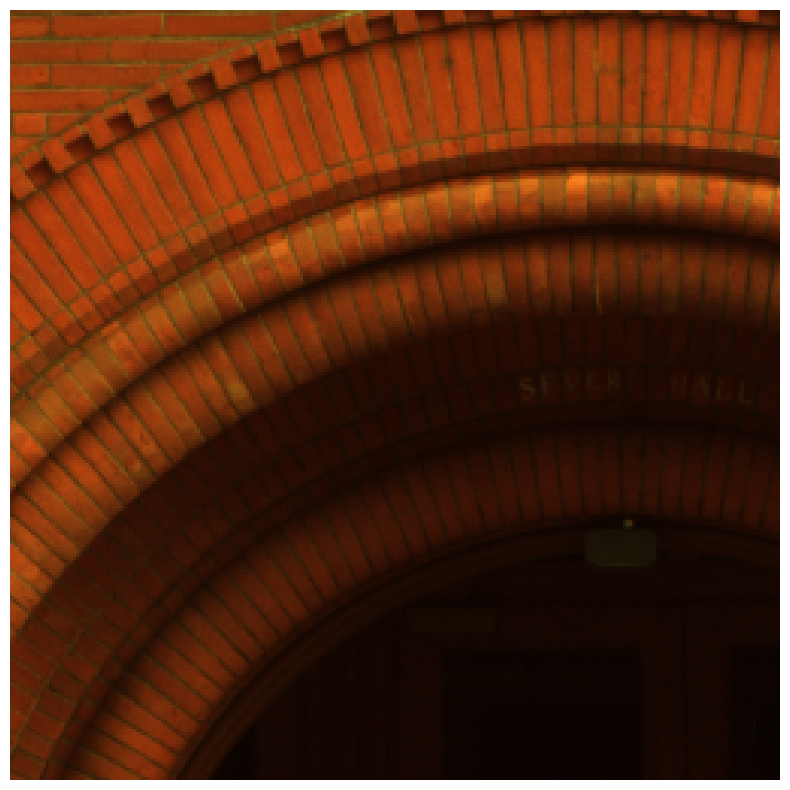

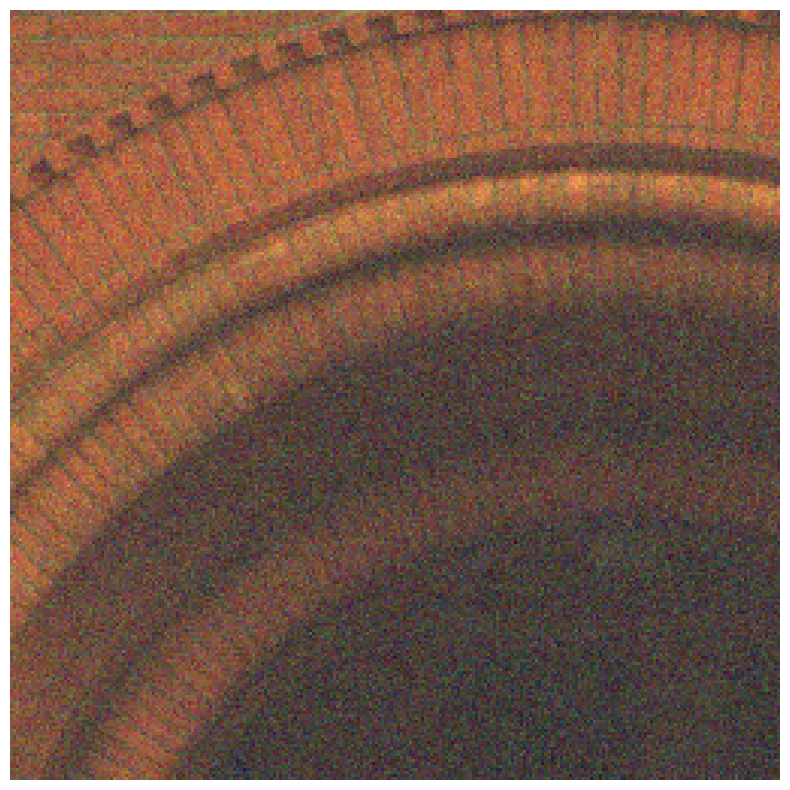

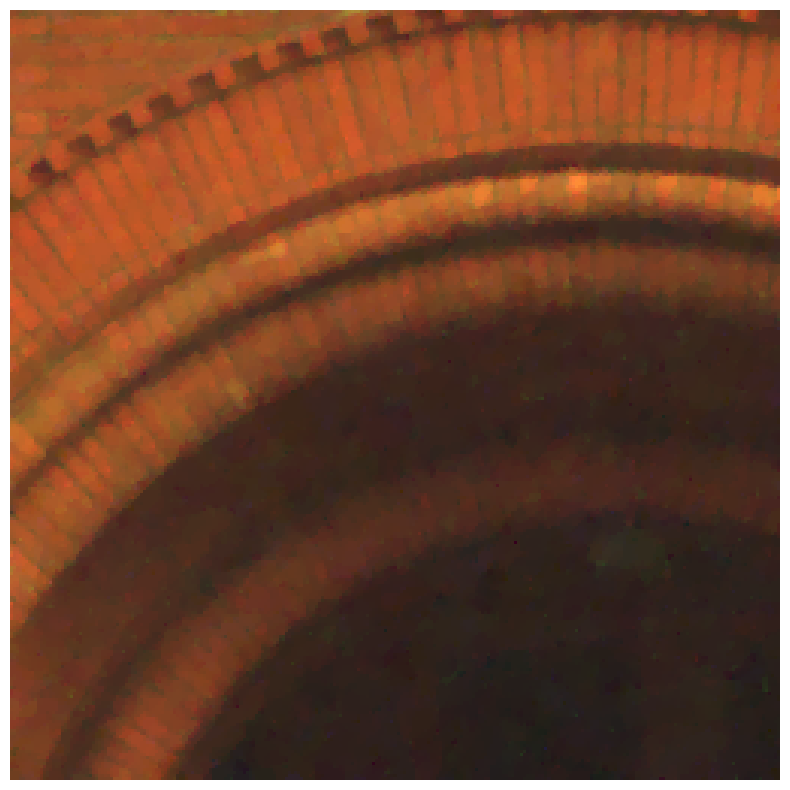

In [37]:
rgb = dataset.rgb_index
x_rgb = X[0, rgb,...].cpu().numpy().transpose(1, 2, 0)
x_rgb = (x_rgb - x_rgb.min())/(x_rgb.max() - x_rgb.min())

y_rgb = observation[0, rgb, ...].cpu().numpy().transpose(1, 2, 0)
y_rgb = (y_rgb - y_rgb.min())/(y_rgb.max() - y_rgb.min())

z_rgb = u[0, rgb, ...].cpu().numpy().transpose(1, 2, 0)
z_rgb = (z_rgb - z_rgb.min())/(z_rgb.max() - z_rgb.min())

# plt.figure(figsize=(15, 5))
# plt.subplot(131)
plt.figure(figsize=(10,10))
plt.imshow(x_rgb)
# plt.title('RGB')
plt.axis('off')

# plt.subplot(133)
plt.figure(figsize=(10,10))
plt.imshow(y_rgb)
# plt.title('Noisy RGB')
plt.axis('off')

# plt.subplot(133)
plt.figure(figsize=(10,10))
plt.imshow(z_rgb)
# plt.title('Noisy RGB')=4
plt.axis('off')

plt.show()

Dimensions vérifiées: iterations (2000,), cout_total 2000


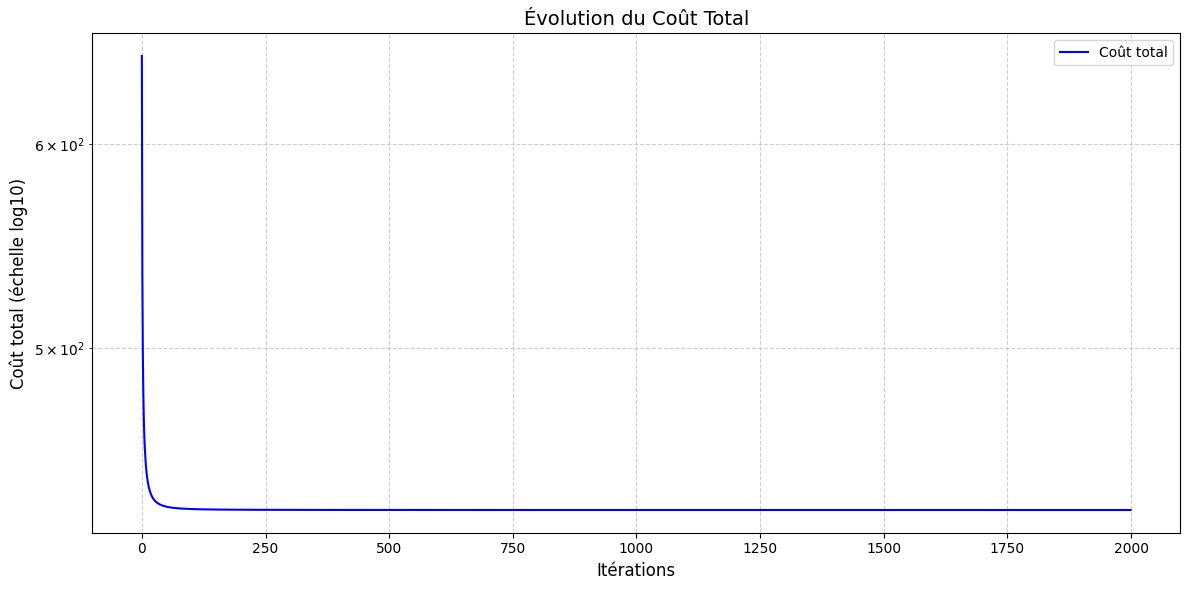

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Données d'exemple (à adapter avec vos données réelles)
cout_total = loss

# Création du vecteur d'itérations de même longueur que cout_total
iterations = np.arange(0, len(cout_total))  # Pas de 10 entre les mesures

# Vérification des dimensions
print(f"Dimensions vérifiées: iterations {iterations.shape}, cout_total {len(cout_total)}")

# Création du graphique
plt.figure(figsize=(12, 6))
plt.semilogy(iterations, cout_total, 'b-', linewidth=1.5, label='Coût total')

# Personnalisation
plt.xlabel('Itérations', fontsize=12)
plt.ylabel('Coût total (échelle log10)', fontsize=12)
plt.title('Évolution du Coût Total', fontsize=14)
plt.grid(True, which="both", linestyle='--', alpha=0.6)

# Affichage
plt.legend()
plt.tight_layout()
plt.show()